In [1]:
import numpy as np 
import pandas as pd 

preprocess_dir = f"../data_analysis1/artifacts/preprocess"
models_dir = f"../data_analysis1/artifacts/models"

X = np.load(f"{preprocess_dir}/data_matrix1.npy")
X_reduced = np.load(f"{preprocess_dir}/data_matrix_reduced.npy")
X_reduced_1 = np.load(f"{preprocess_dir}/data_matrix_reduced1.npy")

y = np.load(f"{preprocess_dir}/y.npy")

import joblib
import json

drop_cols = joblib.load(f"{preprocess_dir}/data_matrix_drop_cols.joblib")

In [2]:
X.shape , X_reduced.shape , X_reduced_1.shape

((85849, 139), (85849, 131), (85849, 65))

In [3]:
y.shape

(85849,)

In [4]:
drop_cols

{'corr_drop_cols': [0, 2, 4, 18, 20, 21, 23, 27],
 'vif_drop_cols': array([  0,   2,   3,   4,   5,   6,   9,  10,  11,  12,  13,  18,  19,
         20,  21,  22,  23,  24,  25,  26,  27,  28,  29,  30,  31,  33,
         34,  35,  36,  37,  38,  39,  40,  41,  42,  43,  44,  45,  46,
         47,  48,  49,  50,  51,  52,  53,  55,  57,  58,  59,  60,  61,
         62,  63,  64,  65,  66,  67,  68,  69,  70,  71,  72,  73,  74,
         75,  79,  80,  83,  84,  85,  86, 135, 136], dtype=int64)}

In [5]:
drop_cols_1 = drop_cols["corr_drop_cols"]
drop_cols_2 = drop_cols["vif_drop_cols"]


In [6]:
import warnings 
warnings.filterwarnings('ignore')

In [7]:
import tensorflow as tf
from tensorflow.keras.models import Sequential,Model
from tensorflow.keras.layers import Input,Dense, Dropout, BatchNormalization, Flatten 
from tensorflow.keras.utils import to_categorical 
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Accuracy , Precision , Recall,AUC


In [8]:
len(drop_cols_1), len(drop_cols_2)

(8, 74)

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [10]:
np.unique(y , return_counts=True)

(array([1, 2, 3, 4, 5], dtype=int64),
 array([11213,  1282,  2557, 11210, 59587], dtype=int64))

In [11]:
import json 
with open(f'{preprocess_dir}/class_weights.json','r') as file:
    class_weights = json.load(file)


print(class_weights)

{'5': 1.44, '1': 7.65, '4': 7.66, '3': 33.58, '2': 66.96}


In [12]:
xtrain ,  xtest ,ytrain ,ytest = train_test_split(X , y , test_size = 0.1 , stratify = y , random_state=42)
xtrain.shape , ytrain.shape , xtest.shape , ytest.shape

((77264, 139), (77264,), (8585, 139), (8585,))

In [13]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    classification_report,
)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np





def evaluate_classification_model1(model, X_train, y_train, X_test, y_test):
    """ This function evaluates a classification model using macro averaging for metrics whereever applicable."""
    
    results = {}

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Probabilities for ROC AUC if available (multiclass classification)
    y_train_prob = model.predict_proba(X_train) if hasattr(model, "predict_proba") else None
    y_test_prob = model.predict_proba(X_test) if hasattr(model, "predict_proba") else None

    # Calculate metrics helper
    def calc_metrics(y_true, y_pred, y_prob=None):
        accuracy = accuracy_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred, zero_division=0, average='macro')
        recall = recall_score(y_true, y_pred, zero_division=0, average='macro')
        f1 = f1_score(y_true, y_pred, zero_division=0, average='macro')
        roc_auc = (
            roc_auc_score(y_true, y_prob, average='macro', multi_class='ovr')
            if y_prob is not None
            else None
        )
        return accuracy, precision, recall, f1, roc_auc

    train_metrics = calc_metrics(y_train, y_train_pred, y_train_prob)
    test_metrics = calc_metrics(y_test, y_test_pred, y_test_prob)

    metric_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']

    # Print metrics
    print("Training Metrics:")
    for name, value in zip(metric_names, train_metrics):
        if value is not None:
            print(f"{name}: {value:.4f}")

    print("\nTesting Metrics:")
    for name, value in zip(metric_names, test_metrics):
        if value is not None:
            print(f"{name}: {value:.4f}")

    # Detailed classification report for test
    print("\nClassification Report (Test):")
    print(classification_report(y_test, y_test_pred, zero_division=0))

    # Confusion matrix plot for test data
    cm = confusion_matrix(y_test, y_test_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title("Confusion Matrix (Test)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # Plot ROC curves per class for multiclass data (One-vs-Rest)
    if y_test_prob is not None:
        classes = np.unique(y_test)
        y_test_binarized = label_binarize(y_test, classes=classes)
        n_classes = y_test_binarized.shape[1]

        plt.figure(figsize=(8, 6))

        for i in range(n_classes):
            fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_test_prob[:, i])
            roc_auc = roc_auc_score(y_test_binarized[:, i], y_test_prob[:, i])
            plt.plot(fpr, tpr, label=f"Class {classes[i]} (AUC = {roc_auc:.2f})")

        plt.plot([0, 1], [0, 1], "k--", label="Random Chance")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("Multiclass ROC Curve (One-vs-Rest)")
        plt.legend()
        plt.grid(True)
        plt.show()

    return {"train_metrics": train_metrics, "test_metrics": test_metrics}


In [18]:
lr = LogisticRegression(random_state = 42 , verbose = 1 , n_jobs=-1)
lr.fit(xtrain,ytrain)

print(lr.score(xtrain,ytrain))
print(lr.score(xtest,ytest))

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


0.7038983226340857
0.7044845661036692


Training Metrics:
Accuracy: 0.7039
Precision: 0.2776
Recall: 0.2200
F1 Score: 0.2015
ROC AUC: 0.6403

Testing Metrics:
Accuracy: 0.7045
Precision: 0.2859
Recall: 0.2202
F1 Score: 0.2020
ROC AUC: 0.6383

Classification Report (Test):
              precision    recall  f1-score   support

           1       0.73      0.11      0.19      1121
           2       0.00      0.00      0.00       128
           3       0.00      0.00      0.00       256
           4       0.00      0.00      0.00      1121
           5       0.70      0.99      0.82      5959

    accuracy                           0.70      8585
   macro avg       0.29      0.22      0.20      8585
weighted avg       0.58      0.70      0.60      8585



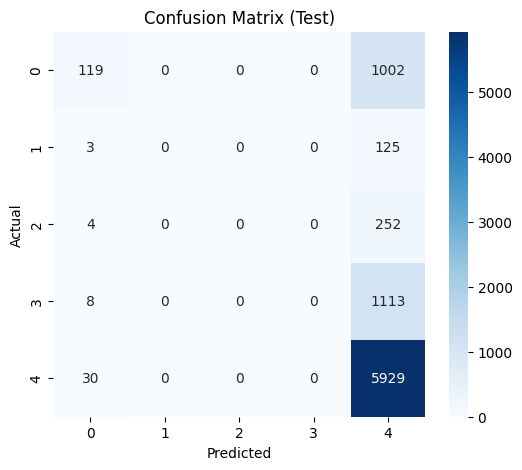

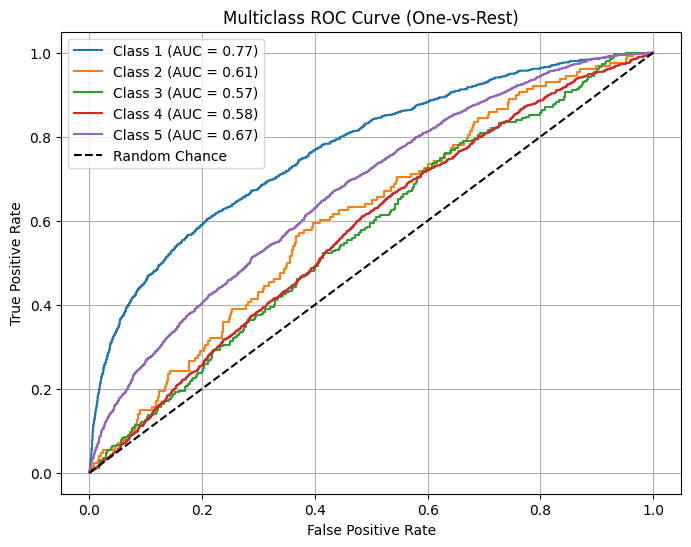

In [19]:
lr_train_metrics, lr_test_metrics = evaluate_classification_model1(lr, xtrain, ytrain, xtest, ytest)

In [20]:

lr1 = LogisticRegression(max_iter=1000 , random_state = 42 , n_jobs=-1 )
lr1.fit(xtrain,ytrain)

print(lr1.score(xtrain,ytrain))
print(lr1.score(xtest,ytest))

0.7168280182232346
0.7172976121141525


Training Metrics:
Accuracy: 0.7168
Precision: 0.2766
Recall: 0.2475
F1 Score: 0.2395
ROC AUC: 0.6643

Testing Metrics:
Accuracy: 0.7173
Precision: 0.2779
Recall: 0.2490
F1 Score: 0.2413
ROC AUC: 0.6625

Classification Report (Test):
              precision    recall  f1-score   support

           1       0.67      0.26      0.38      1121
           2       0.00      0.00      0.00       128
           3       0.00      0.00      0.00       256
           4       0.00      0.00      0.00      1121
           5       0.72      0.98      0.83      5959

    accuracy                           0.72      8585
   macro avg       0.28      0.25      0.24      8585
weighted avg       0.59      0.72      0.63      8585



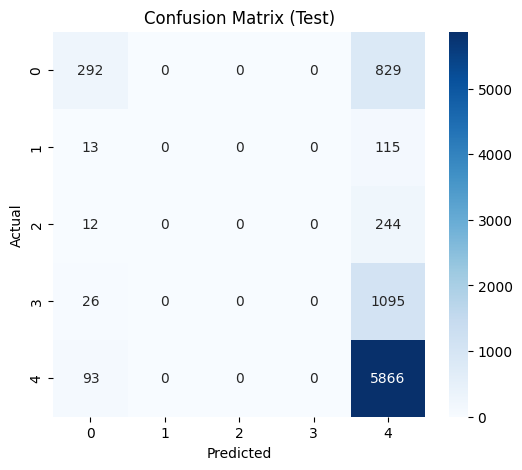

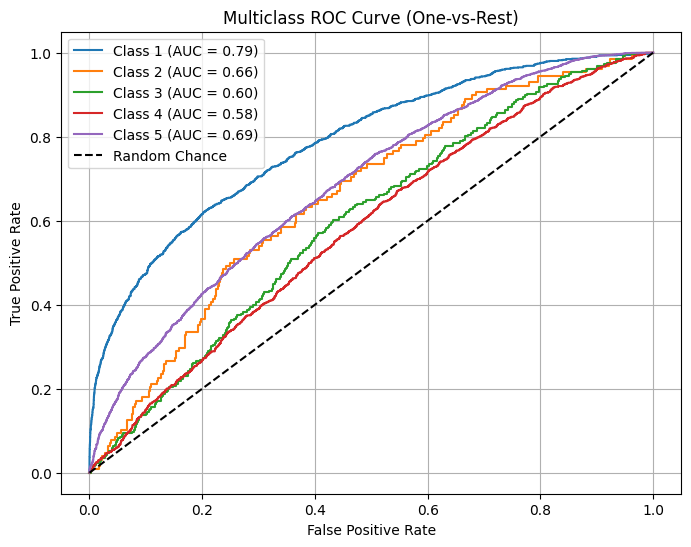

In [ ]:
lr1_train_metrics, lr1_test_metrics = evaluate_classification_model1(lr1, xtrain, ytrain, xtest, ytest)

# Lower precision_score indicates higher cases of False Positives.Since it is multiclass classification , it indicates that some classes are being misclassified as other classes.


# Lower recall score indicates higher cases of False negatives.Since it is macro recall , it takes the arithmetic mean of all class recalls , treating all classes equally regardless of their frequency.Thereby the lower macro recall indicates that the model is giving higher number of false negatives across overall all classes.

# ROC AUC = 0.66 means that the model has a 66% chance of distinguishing between classes, which is better than random guessing but indicates room for improvement.This is macro roc : all classes ROC averaged.

# Classification report precision,recall , f1 are 0 for 2 , 3 , 4 indicates that the model is not predicting any instances of these classes correctly, likely due to class imbalance or insufficient training data for these classes.It indicates that TP = 0 for these classes. 
# Similarly recall is also 0 for these classes indicating that the model is not able to identify any actual instances of these classes correctly.
# Overall , the model performs well on the majority class (class 5) and the class 1 , but struggles with minority classes (2, 3, 4) likely due to class imbalance.



In [14]:
class_weights

{'5': 1.44, '1': 7.65, '4': 7.66, '3': 33.58, '2': 66.96}

In [15]:
class_weights_int = {int(key) : value for key , value in class_weights.items()}
class_weights_int

{5: 1.44, 1: 7.65, 4: 7.66, 3: 33.58, 2: 66.96}

In [16]:

lr2 = LogisticRegression(max_iter=1000 , class_weight='balanced', random_state=42)
lr2.fit(xtrain,ytrain)

print(lr2.score(xtrain,ytrain))
print(lr2.score(xtest,ytest))

0.3478075170842825
0.3507280139778684


Training Metrics:
Accuracy: 0.3478
Precision: 0.2883
Recall: 0.3175
F1 Score: 0.2431
ROC AUC: 0.6450

Testing Metrics:
Accuracy: 0.3507
Precision: 0.2903
Recall: 0.3033
F1 Score: 0.2430
ROC AUC: 0.6417

Classification Report (Test):
              precision    recall  f1-score   support

           1       0.39      0.45      0.42      1121
           2       0.02      0.30      0.04       128
           3       0.03      0.17      0.05       256
           4       0.16      0.24      0.19      1121
           5       0.84      0.36      0.51      5959

    accuracy                           0.35      8585
   macro avg       0.29      0.30      0.24      8585
weighted avg       0.66      0.35      0.43      8585



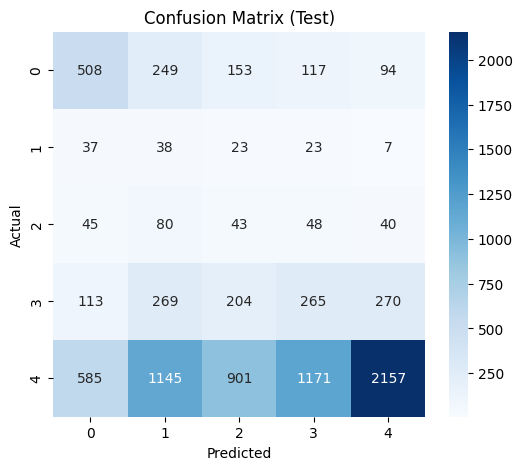

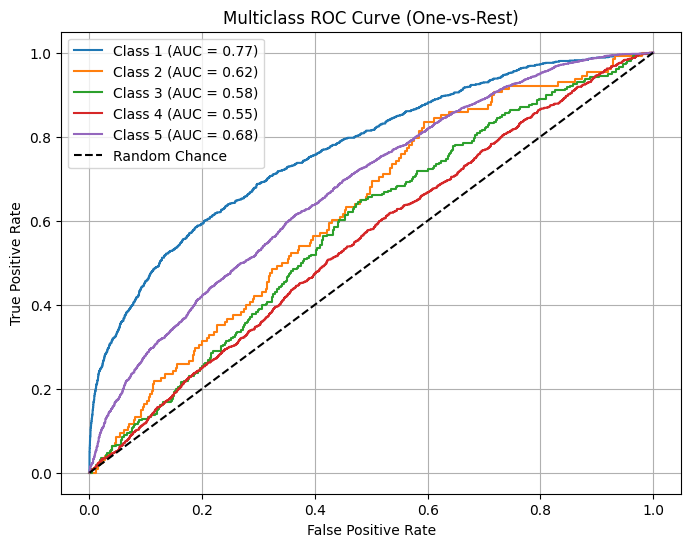

In [17]:
lr2_train_metrics, lr2_test_metrics = evaluate_classification_model1(lr2, xtrain, ytrain, xtest, ytest)

In [19]:
lr3 = LogisticRegression(max_iter=1000 , class_weight=class_weights_int, random_state=42)
lr3.fit(xtrain,ytrain)

print(lr3.score(xtrain,ytrain))
print(lr3.score(xtest,ytest))

0.3416079933733692
0.3482818870122306


Creating RF , XGB , DNN for this dataset 

In [20]:
rf1 = RandomForestClassifier(random_state = 42,n_jobs=-1 , n_estimators=200 , max_depth=10)

rf1.fit(xtrain,ytrain)

print(rf1.score(xtrain,ytrain))
print(rf1.score(xtest,ytest))

0.7163361979705943
0.7129877693651718


Training Metrics:
Accuracy: 0.7163
Precision: 0.3132
Recall: 0.2360
F1 Score: 0.2263
ROC AUC: 0.7523

Testing Metrics:
Accuracy: 0.7130
Precision: 0.3033
Recall: 0.2325
F1 Score: 0.2211
ROC AUC: 0.6766

Classification Report (Test):
              precision    recall  f1-score   support

           1       0.81      0.17      0.28      1121
           2       0.00      0.00      0.00       128
           3       0.00      0.00      0.00       256
           4       0.00      0.00      0.00      1121
           5       0.71      1.00      0.83      5959

    accuracy                           0.71      8585
   macro avg       0.30      0.23      0.22      8585
weighted avg       0.60      0.71      0.61      8585



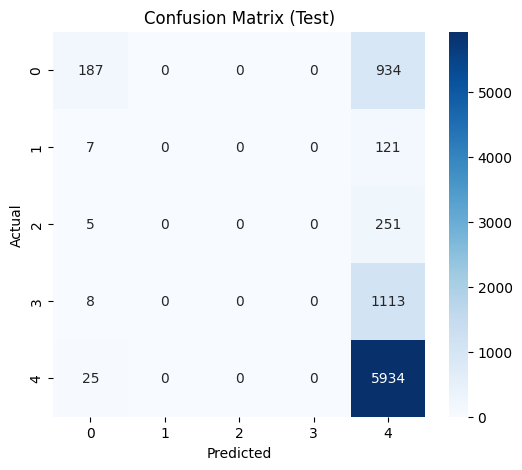

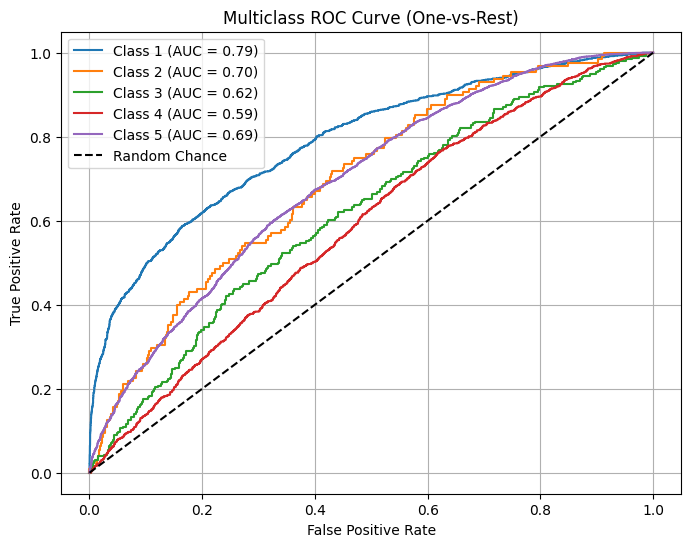

In [21]:
rf1_train_metrics, rf1_test_metrics = evaluate_classification_model1(rf1, xtrain , ytrain , xtest , ytest)

In [22]:
rf2 = RandomForestClassifier(random_state = 42,n_jobs=-1 , n_estimators=200 , max_depth=10 , class_weight='balanced')

rf2.fit(xtrain,ytrain)

print(rf2.score(xtrain,ytrain))
print(rf2.score(xtest,ytest))

0.4508050320977428
0.4172393709959231


Training Metrics:
Accuracy: 0.4508
Precision: 0.3369
Recall: 0.4623
F1 Score: 0.3332
ROC AUC: 0.7673

Testing Metrics:
Accuracy: 0.4172
Precision: 0.2927
Recall: 0.3242
F1 Score: 0.2709
ROC AUC: 0.6558

Classification Report (Test):
              precision    recall  f1-score   support

           1       0.38      0.52      0.44      1121
           2       0.03      0.14      0.05       128
           3       0.04      0.16      0.07       256
           4       0.17      0.39      0.23      1121
           5       0.84      0.42      0.56      5959

    accuracy                           0.42      8585
   macro avg       0.29      0.32      0.27      8585
weighted avg       0.65      0.42      0.48      8585



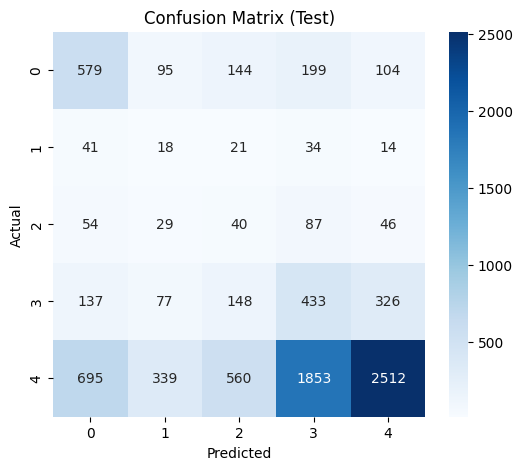

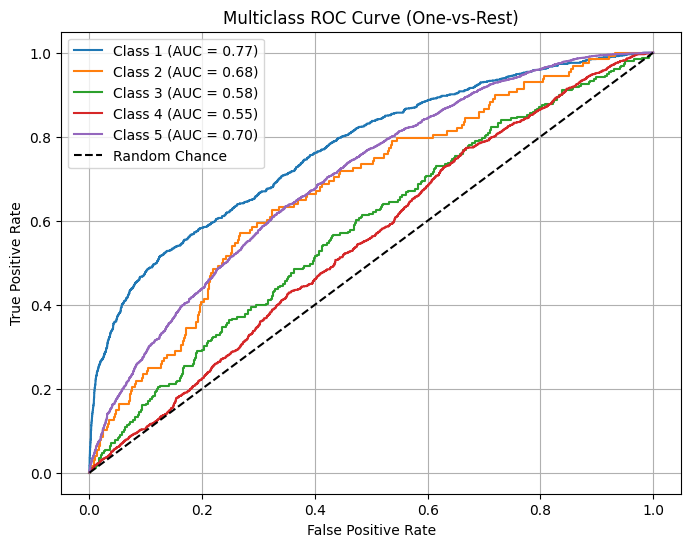

In [23]:
rf2_train_metrics, rf2_test_metrics=evaluate_classification_model1(rf2, xtrain , ytrain , xtest , ytest)

In [24]:
rf3 = RandomForestClassifier(random_state = 42,n_jobs=-1 , n_estimators=200 , max_depth=20 , class_weight="balanced")

rf3.fit(xtrain,ytrain)

print(rf3.score(xtrain,ytrain))
print(rf3.score(xtest,ytest))

0.8864283495547732
0.6357600465928945


Training Metrics:
Accuracy: 0.8864
Precision: 0.7792
Recall: 0.8782
F1 Score: 0.8216
ROC AUC: 0.9632

Testing Metrics:
Accuracy: 0.6358
Precision: 0.2905
Recall: 0.2874
F1 Score: 0.2884
ROC AUC: 0.6466

Classification Report (Test):
              precision    recall  f1-score   support

           1       0.47      0.45      0.46      1121
           2       0.00      0.00      0.00       128
           3       0.04      0.04      0.04       256
           4       0.18      0.15      0.17      1121
           5       0.76      0.80      0.78      5959

    accuracy                           0.64      8585
   macro avg       0.29      0.29      0.29      8585
weighted avg       0.61      0.64      0.62      8585



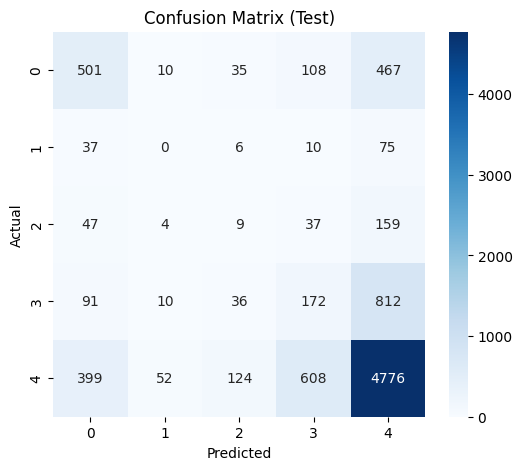

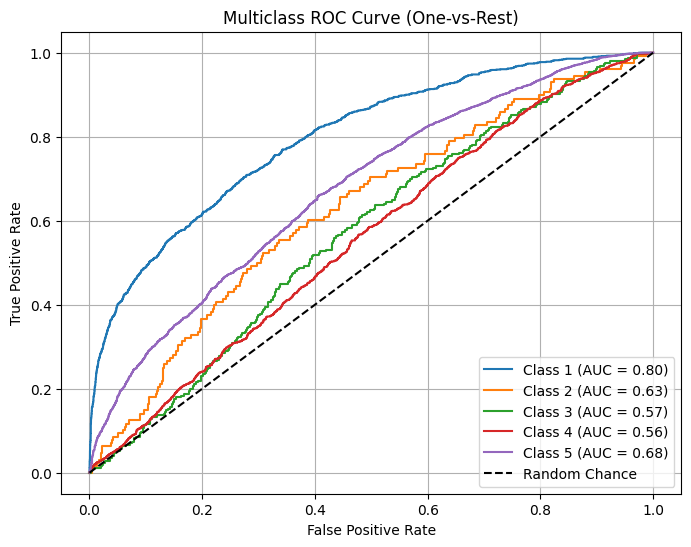

In [25]:
rf3_train_metrics, rf3_test_metrics = evaluate_classification_model1(rf3, xtrain, ytrain, xtest, ytest)

In [30]:
class_weights_int_xgb = {key-1 : value for key, value in class_weights_int.items()}
class_weights_int_xgb

{4: 1.44, 0: 7.65, 3: 7.66, 2: 33.58, 1: 66.96}

In [35]:
# Trying XGB

classes = np.unique(y)-1
sample_weights = np.array([class_weights_int_xgb[label] for label in ytrain-1])


xgb1 = XGBClassifier(random_state=42,objective = 'multi:softmax' )
xgb1.fit(xtrain, ytrain-1, sample_weight=sample_weights)


,objective,'multi:softmax'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [36]:
xgb1.score(xtrain,ytrain-1) , xgb1.score(xtest,ytest-1)

(0.5402127769724581, 0.4399534071054164)

Training Metrics:
Accuracy: 0.5402
Precision: 0.4050
Recall: 0.6523
F1 Score: 0.4276
ROC AUC: 0.8566

Testing Metrics:
Accuracy: 0.4400
Precision: 0.2866
Recall: 0.3038
F1 Score: 0.2684
ROC AUC: 0.6443

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.41      0.48      0.44      1121
           1       0.03      0.16      0.05       128
           2       0.03      0.12      0.05       256
           3       0.15      0.28      0.20      1121
           4       0.81      0.48      0.61      5959

    accuracy                           0.44      8585
   macro avg       0.29      0.30      0.27      8585
weighted avg       0.64      0.44      0.51      8585



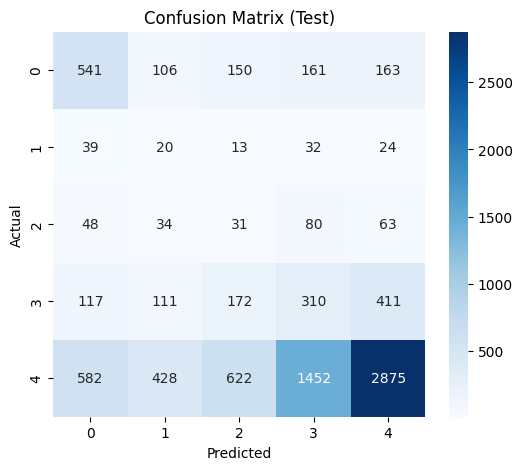

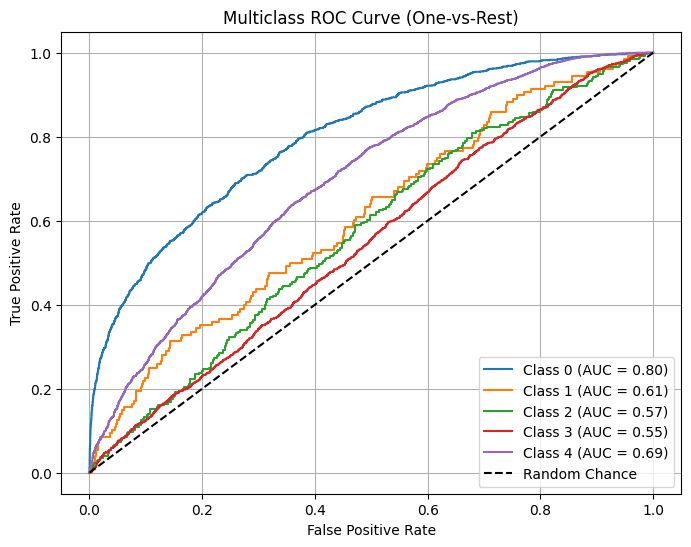

In [37]:
xgb1_train_metrics, xgb1_test_metrics=evaluate_classification_model1(xgb1, xtrain, ytrain-1, xtest, ytest-1)

In [38]:
xgb2 = XGBClassifier(random_state=42,
         n_estimators = 200,
         max_depth = 20,
         learning_rate = 0.1,
         objective = 'multi:softmax' )
xgb2.fit(xtrain, ytrain-1, sample_weight=sample_weights)

,objective,'multi:softmax'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [39]:
xgb2.score(xtrain,ytrain-1) , xgb2.score(xtest,ytest-1)

(0.9990034168564921, 0.6774606872451951)

Training Metrics:
Accuracy: 0.9990
Precision: 0.9983
Recall: 0.9997
F1 Score: 0.9990
ROC AUC: 1.0000

Testing Metrics:
Accuracy: 0.6775
Precision: 0.3045
Recall: 0.2700
F1 Score: 0.2694
ROC AUC: 0.6396

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.49      0.38      0.43      1121
           1       0.00      0.00      0.00       128
           2       0.14      0.01      0.01       256
           3       0.15      0.07      0.09      1121
           4       0.74      0.89      0.81      5959

    accuracy                           0.68      8585
   macro avg       0.30      0.27      0.27      8585
weighted avg       0.60      0.68      0.63      8585



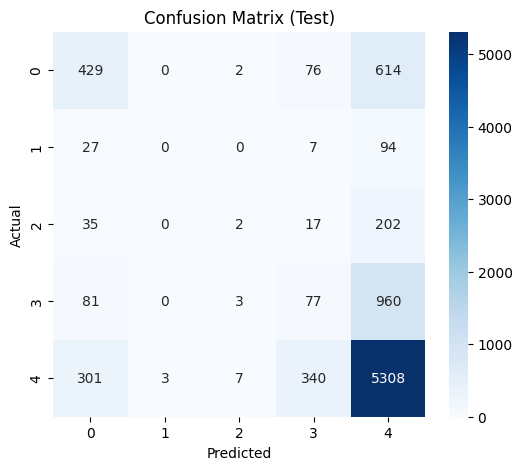

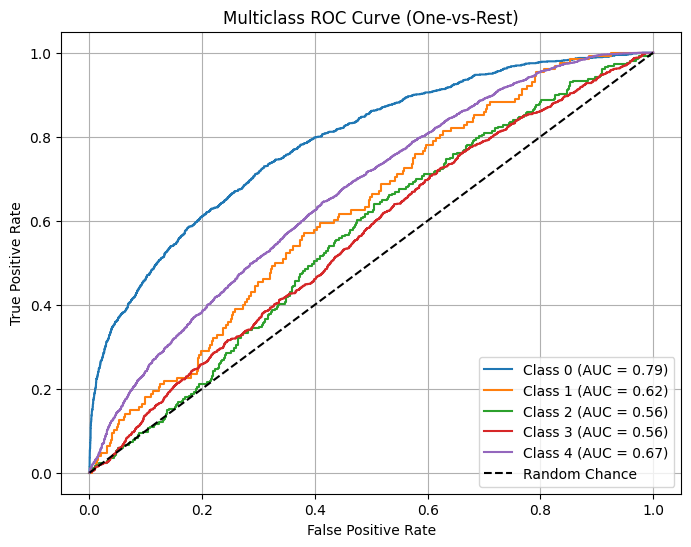

In [40]:
xgb2_train_metrics, xgb2_test_metrics=evaluate_classification_model1(xgb2, xtrain, ytrain-1, xtest, ytest-1)

Now trying ann models

In [41]:
import tensorflow as tf
tf.__version__

'2.10.0'

In [73]:
classes = np.unique(y)-1
n_classes = len(classes)

In [78]:

# Model creation
ann1 = Sequential()
ann1.add(Input(shape=(xtrain.shape[1],)))
ann1.add(Dense(128, activation='relu',))
ann1.add(Dense(64 , activation = 'relu'))
ann1.add(Dense(n_classes , activation = 'softmax') )

ann1.summary()

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_18 (Dense)            (None, 128)               17920     
                                                                 
 dense_19 (Dense)            (None, 64)                8256      
                                                                 
 dense_20 (Dense)            (None, 5)                 325       
                                                                 
Total params: 26,501
Trainable params: 26,501
Non-trainable params: 0
_________________________________________________________________


In [79]:
# Model_compilation



ann1.compile(optimizer=Adam(learning_rate=0.1), 
             loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False), metrics=['accuracy'])

In [80]:

from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import EarlyStopping

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5 , mode = 'min' , min_lr = 0.0001)

early_stop = EarlyStopping(monitor= 'val_loss',
                           patience = 20,
                           verbose = 1 ,
                           mode = 'min' ,
                           restore_best_weights = True)


In [81]:
# Fit the model 

history = ann1.fit(xtrain, ytrain-1,
                   validation_data=(xtest, ytest-1), epochs=100, 
                   batch_size=32,
             callbacks = [reduce_lr , early_stop])    

Epoch 1/100
2415/2415 [==============================] - 7s 3ms/step - loss: 12.4575 - accuracy: 0.6907 - val_loss: 0.9630 - val_accuracy: 0.6941 - lr: 0.1000
Epoch 2/100
2415/2415 [==============================] - 6s 3ms/step - loss: 0.9593 - accuracy: 0.6940 - val_loss: 0.9585 - val_accuracy: 0.6941 - lr: 0.1000
Epoch 3/100
2415/2415 [==============================] - 6s 2ms/step - loss: 0.9587 - accuracy: 0.6941 - val_loss: 0.9621 - val_accuracy: 0.6941 - lr: 0.1000
Epoch 4/100
2415/2415 [==============================] - 6s 3ms/step - loss: 0.9587 - accuracy: 0.6941 - val_loss: 0.9576 - val_accuracy: 0.6941 - lr: 0.1000
Epoch 5/100
2415/2415 [==============================] - 7s 3ms/step - loss: 0.9590 - accuracy: 0.6941 - val_loss: 0.9544 - val_accuracy: 0.6941 - lr: 0.1000
Epoch 6/100
2415/2415 [==============================] - 6s 2ms/step - loss: 0.9584 - accuracy: 0.6941 - val_loss: 0.9537 - val_accuracy: 0.6941 - lr: 0.1000
Epoch 7/100
2415/2415 [============================

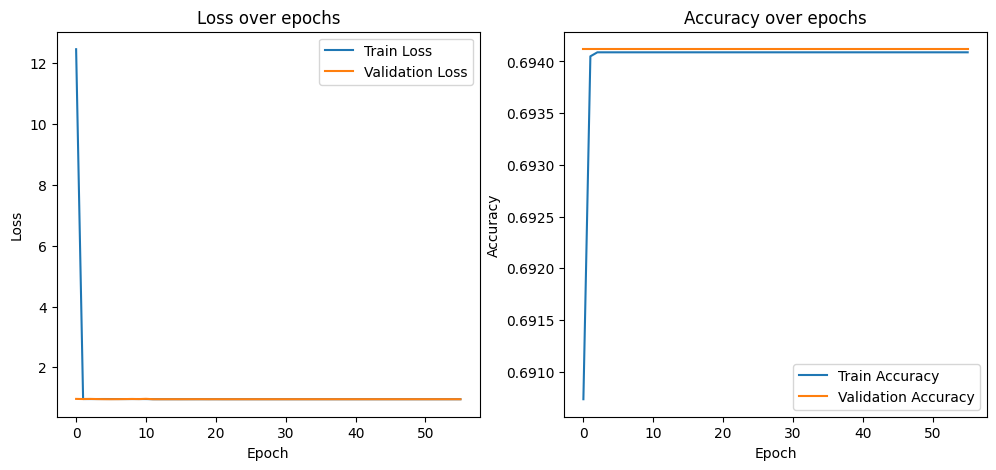

In [82]:

# Plot Loss

def performance_plots(history):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss over epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Plot Accuracy (or another metric you used, e.g. precision)
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy over epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.show()

performance_plots(history)


The graphs shows that the model reached its peak performance quite early in the epochs and thereafter no further improvement happened on loss decrease and accuracy increase . The accuracy became stagnant at 0.6941 for both training and validation sets . The models shows not overfitting.

In [83]:
# from sklearn.metrics import f1_score
# import numpy as np
def metrics_eval(model, X_test, y_test):
   
    y_pred_prob = model.predict(X_test)  # shape: (n_samples, n_classes)
    y_pred = np.argmax(y_pred_prob, axis=1)  # class with highest probability

    f1 = f1_score(y_test, y_pred, average='macro')  # or 'weighted', 'micro' based on your needs
    print(f"F1 Score : {f1:.4f}")

    precision = precision_score(y_test, y_pred, average='macro')
    recall = recall_score(y_test, y_pred, average='macro')
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")


In [84]:

metrics_eval(ann1, xtest, ytest-1)



269/269 [==============================] - 1s 2ms/step
F1 Score : 0.1639
Precision: 0.1388
Recall: 0.2000


ANN model2 : Making it more deeper and there complex that may be able to capture more underlying patterns in the data to reduce the bias occuring in the model training

In [85]:
# Model creation

ann2 = Sequential()
ann2.add(Input(shape=(xtrain.shape[1],)))
ann2.add(Dense(256, activation='relu',))
ann2.add(Dense(128, activation='relu',))
ann2.add(Dense(64 , activation = 'relu'))
ann2.add(Dense(n_classes , activation = 'softmax') )

ann2.summary()

Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_21 (Dense)            (None, 256)               35840     
                                                                 
 dense_22 (Dense)            (None, 128)               32896     
                                                                 
 dense_23 (Dense)            (None, 64)                8256      
                                                                 
 dense_24 (Dense)            (None, 5)                 325       
                                                                 
Total params: 77,317
Trainable params: 77,317
Non-trainable params: 0
_________________________________________________________________


In [86]:
# Model_compilation

ann2.compile(optimizer=Adam(learning_rate=0.1), loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False), metrics=['accuracy'])


In [87]:

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=3 , mode = 'min' , min_lr = 0.0001)

early_stop = EarlyStopping(monitor= 'val_loss',
                           patience = 6,
                           verbose = 1 ,
                           mode = 'min' ,
                           restore_best_weights = True)

# Fit the model 

history1 = ann1.fit(xtrain, ytrain-1, validation_data=(xtest, ytest-1), epochs=50, batch_size=32,
                    callbacks = [reduce_lr , early_stop])    





Epoch 1/50
2415/2415 [==============================] - 6s 3ms/step - loss: 0.9526 - accuracy: 0.6941 - val_loss: 0.9525 - val_accuracy: 0.6941 - lr: 1.0000e-04
Epoch 2/50
2415/2415 [==============================] - 6s 2ms/step - loss: 0.9526 - accuracy: 0.6941 - val_loss: 0.9525 - val_accuracy: 0.6941 - lr: 1.0000e-04
Epoch 3/50
2415/2415 [==============================] - 7s 3ms/step - loss: 0.9526 - accuracy: 0.6941 - val_loss: 0.9525 - val_accuracy: 0.6941 - lr: 1.0000e-04
Epoch 4/50
2415/2415 [==============================] - 7s 3ms/step - loss: 0.9526 - accuracy: 0.6941 - val_loss: 0.9525 - val_accuracy: 0.6941 - lr: 1.0000e-04
Epoch 5/50
2415/2415 [==============================] - 7s 3ms/step - loss: 0.9526 - accuracy: 0.6941 - val_loss: 0.9525 - val_accuracy: 0.6941 - lr: 1.0000e-04
Epoch 6/50
2415/2415 [==============================] - 9s 4ms/step - loss: 0.9526 - accuracy: 0.6941 - val_loss: 0.9525 - val_accuracy: 0.6941 - lr: 1.0000e-04
Epoch 7/50
2415/2415 [============

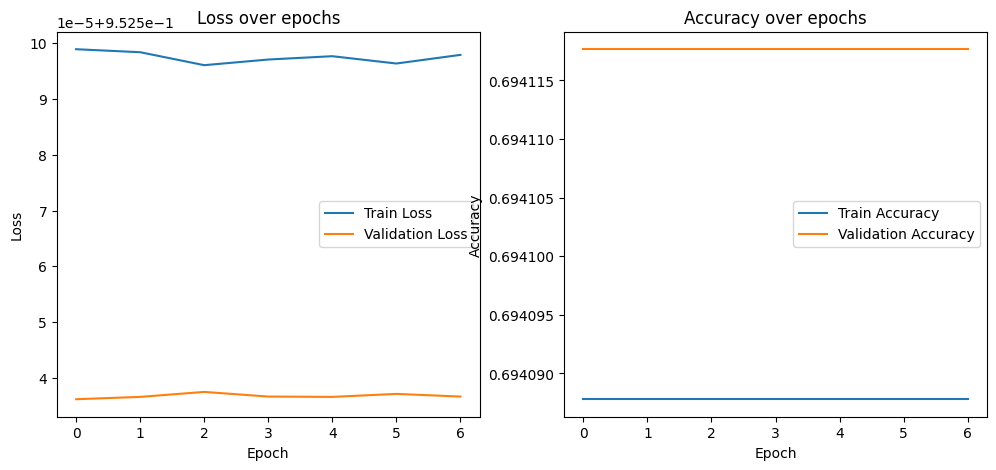

In [88]:
performance_plots(history1)

In [89]:
#Evaluate metrics : Precision , Recall , F1 score 

metrics_eval(ann2, xtest, ytest-1)

269/269 [==============================] - 0s 1000us/step
F1 Score : 0.0634
Precision: 0.1764
Recall: 0.2006


In [91]:
# y binarized

def binarize(y):
    return np.where(y >= 3, 1, 0)


# y_binarized = binarize(y)

In [92]:
ytrain_binarized = binarize(ytrain)
ytest_binarized = binarize(ytest)

print(np.unique(ytrain_binarized , return_counts= True))

print(np.unique(ytest_binarized , return_counts= True))

(array([0, 1]), array([11246, 66018], dtype=int64))
(array([0, 1]), array([1249, 7336], dtype=int64))


After binarization we can see that minority class 1/6th times the majority class in both the arrays.

In [101]:
# Calculating binary class weights

class_counts = np.unique(ytrain_binarized,return_counts=True)
total_counts = len(ytrain_binarized)
class_weights_binary = {cls : round(total_counts/count,2) for cls,count in zip(class_counts[0] , class_counts[1])}
class_weights_binary


{0: 6.87, 1: 1.17}

Model creation for binary classification


In [103]:
lr3.fit(xtrain,ytrain_binarized)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,500
,multi_class,'deprecated'


In [104]:

import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_binary_classification(model, X_train, y_train, X_test, y_test):
    """
    Evaluate a binary classification model with metrics and visualizations.
    """
    
    # Step 1: Get predictions (0 or 1)
    y_train_pred = (model.predict(X_train) > 0.5).astype(int)
    y_test_pred = (model.predict(X_test) > 0.5).astype(int)
    
    # Step 2: Get probabilities (for ROC-AUC calculation)
    y_train_prob = model.predict(X_train).ravel()
    y_test_prob = model.predict(X_test).ravel()
    
    # Step 3: Calculate metrics
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    
    train_precision = precision_score(y_train, y_train_pred)
    test_precision = precision_score(y_test, y_test_pred)
    
    train_recall = recall_score(y_train, y_train_pred)
    test_recall = recall_score(y_test, y_test_pred)
    
    train_f1 = f1_score(y_train, y_train_pred)
    test_f1 = f1_score(y_test, y_test_pred)
    
    train_roc_auc = roc_auc_score(y_train, y_train_prob)
    test_roc_auc = roc_auc_score(y_test, y_test_prob)
    
    # Step 4: Print metrics
    print("=" * 50)
    print("TRAINING METRICS")
    print("=" * 50)
    print(f"Accuracy:  {train_accuracy:.4f}")
    print(f"Precision: {train_precision:.4f}")
    print(f"Recall:    {train_recall:.4f}")
    print(f"F1 Score:  {train_f1:.4f}")
    print(f"ROC AUC:   {train_roc_auc:.4f}")
    
    print("\n" + "=" * 50)
    print("TESTING METRICS")
    print("=" * 50)
    print(f"Accuracy:  {test_accuracy:.4f}")
    print(f"Precision: {test_precision:.4f}")
    print(f"Recall:    {test_recall:.4f}")
    print(f"F1 Score:  {test_f1:.4f}")
    print(f"ROC AUC:   {test_roc_auc:.4f}")
    
    # Step 5: Print detailed classification report
    print("\n" + "=" * 50)
    print("CLASSIFICATION REPORT (TEST DATA)")
    print("=" * 50)
    print(classification_report(y_test, y_test_pred))
    
    # Step 6: Plot confusion matrix
    cm = confusion_matrix(y_test, y_test_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title("Confusion Matrix (Test Data)")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()
    
    # Step 7: Plot ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_test_prob)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {test_roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Model')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()




TRAINING METRICS
Accuracy:  0.7589
Precision: 0.9231
Recall:    0.7831
F1 Score:  0.8474
ROC AUC:   0.7001

TESTING METRICS
Accuracy:  0.7597
Precision: 0.9229
Recall:    0.7844
F1 Score:  0.8480
ROC AUC:   0.6996

CLASSIFICATION REPORT (TEST DATA)
              precision    recall  f1-score   support

           0       0.33      0.61      0.43      1249
           1       0.92      0.78      0.85      7336

    accuracy                           0.76      8585
   macro avg       0.62      0.70      0.64      8585
weighted avg       0.84      0.76      0.79      8585



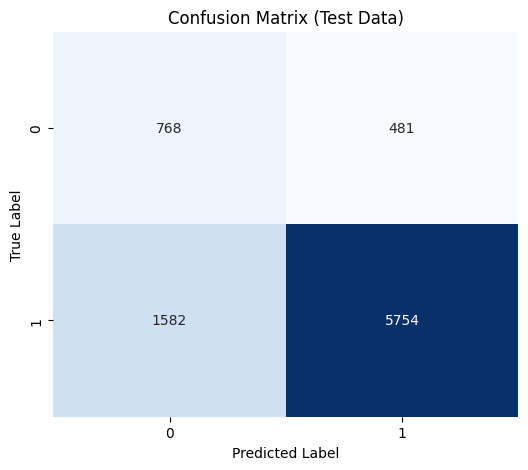

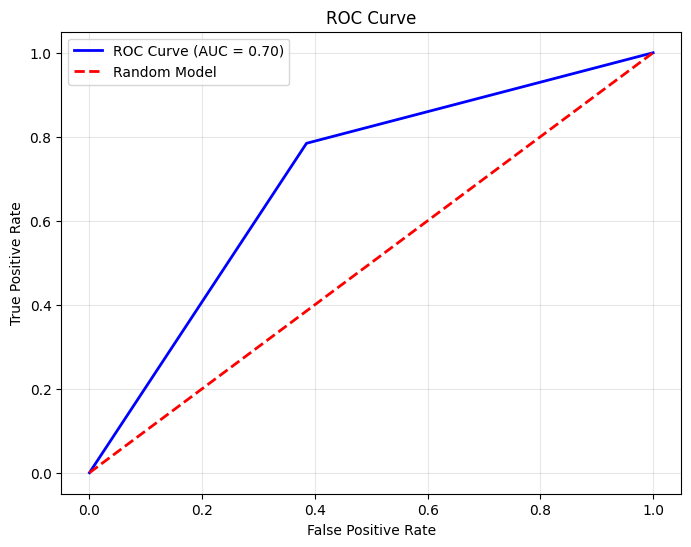

In [106]:
evaluate_binary_classification(lr3 , xtrain,ytrain_binarized,xtest,ytest_binarized)

In [107]:
lr4 = LogisticRegression(max_iter=500 , class_weight='balanced', random_state=42)
lr4.fit(xtrain,ytrain_binarized)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,500
,multi_class,'deprecated'


TRAINING METRICS
Accuracy:  0.7589
Precision: 0.9231
Recall:    0.7831
F1 Score:  0.8474
ROC AUC:   0.7001

TESTING METRICS
Accuracy:  0.7597
Precision: 0.9229
Recall:    0.7844
F1 Score:  0.8480
ROC AUC:   0.6996

CLASSIFICATION REPORT (TEST DATA)
              precision    recall  f1-score   support

           0       0.33      0.61      0.43      1249
           1       0.92      0.78      0.85      7336

    accuracy                           0.76      8585
   macro avg       0.62      0.70      0.64      8585
weighted avg       0.84      0.76      0.79      8585



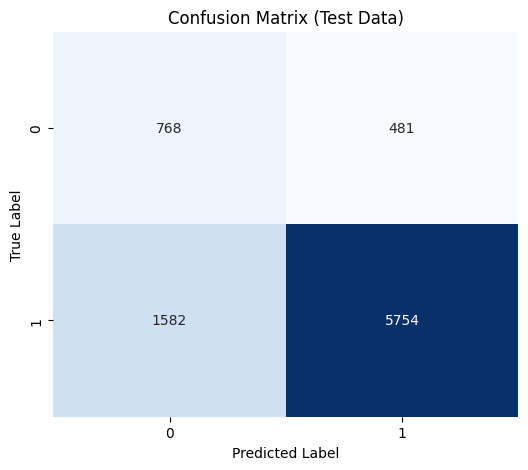

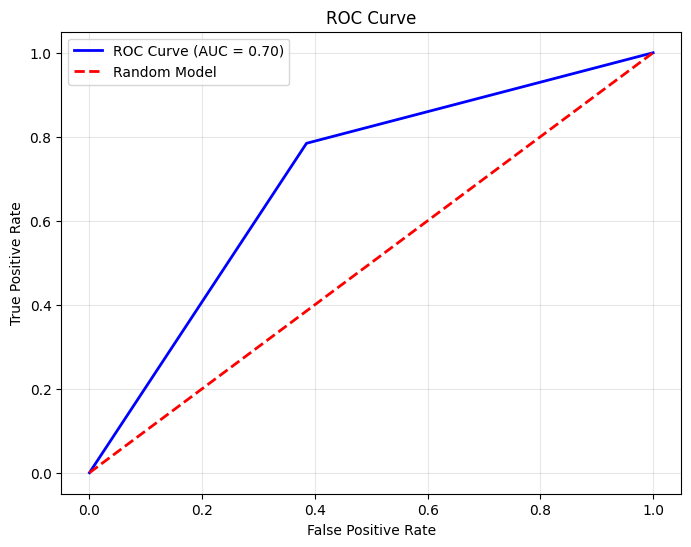

In [108]:
evaluate_binary_classification(lr4 , xtrain,ytrain_binarized,xtest,ytest_binarized)

# Yhan se suru krna hai ab 

Training Metrics:
Accuracy: 0.7508
Precision: 0.9253
Recall: 0.7706
F1 Score: 0.8409
ROC AUC: 0.7804

Testing Metrics:
Accuracy: 0.7462
Precision: 0.9253
Recall: 0.7647
F1 Score: 0.8374
ROC AUC: 0.7762

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.32      0.64      0.42      1250
           1       0.93      0.76      0.84      7335

    accuracy                           0.75      8585
   macro avg       0.62      0.70      0.63      8585
weighted avg       0.84      0.75      0.78      8585



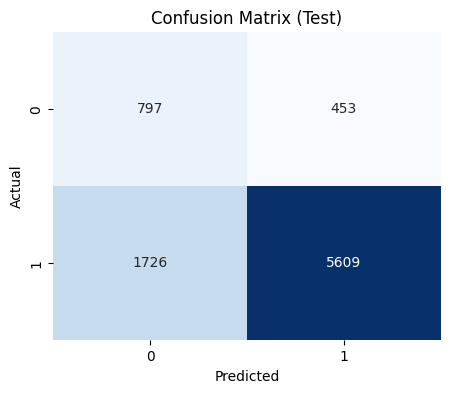

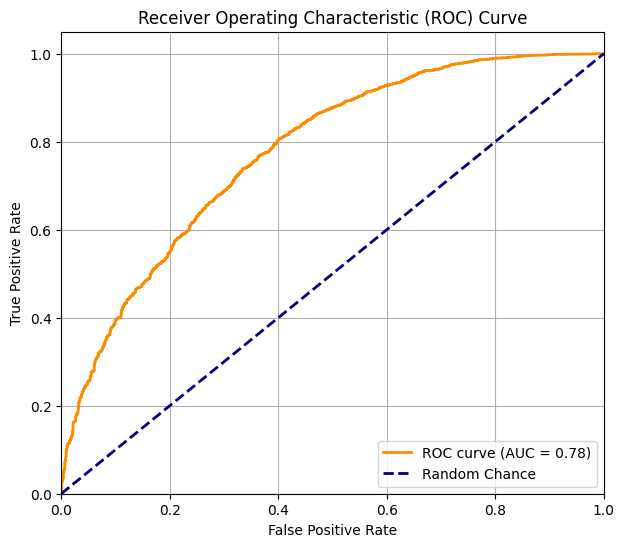

In [56]:
lr4 = LogisticRegression(max_iter=1000 , class_weight='balanced', random_state=42 , n_jobs=-1)
lr4.fit(xtrain1,ytrain1)
lr4_train_metrics , lr4_test_metrics = evaluate_classification_model_binary(lr4 , xtrain1 , ytrain1 , xtest1 , ytest1)

xgb model for binary data

In [ ]:
# xgb_model = XGBClassifier(
#     objective='binary:logistic',  # Binary classification
#     eval_metric='logloss',
#     use_label_encoder=False,
#     random_state=42,
#     n_estimators=100,
#     learning_rate=0.1,
#     max_depth=5
# )

In [58]:
from pandas.core.common import random_state
from sklearn.utils import class_weight
import numpy as np

classes = np.unique(ytrain1)
class_weights = class_weight.compute_class_weight(class_weight='balanced', classes=classes, y=ytrain1)
weight_dict = dict(zip(classes, class_weights))
sample_weights = np.array([weight_dict[c] for c in ytrain1])

xgb2 = XGBClassifier(random_state=42 , n_jobs = -1)
xgb2.fit(xtrain1, ytrain1, sample_weight=sample_weights)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


Training Metrics:
Accuracy: 0.7941
Precision: 0.9534
Recall: 0.7980
F1 Score: 0.8688
ROC AUC: 0.8736

Testing Metrics:
Accuracy: 0.7570
Precision: 0.9271
Recall: 0.7767
F1 Score: 0.8453
ROC AUC: 0.7833

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.33      0.64      0.43      1250
           1       0.93      0.78      0.85      7335

    accuracy                           0.76      8585
   macro avg       0.63      0.71      0.64      8585
weighted avg       0.84      0.76      0.79      8585



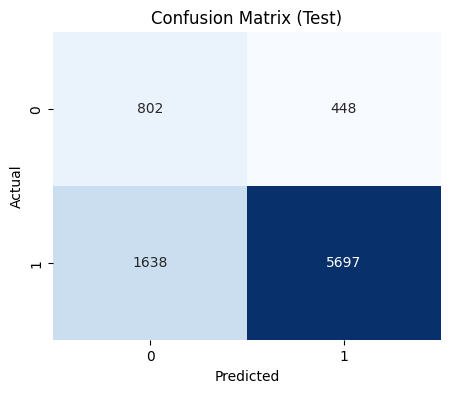

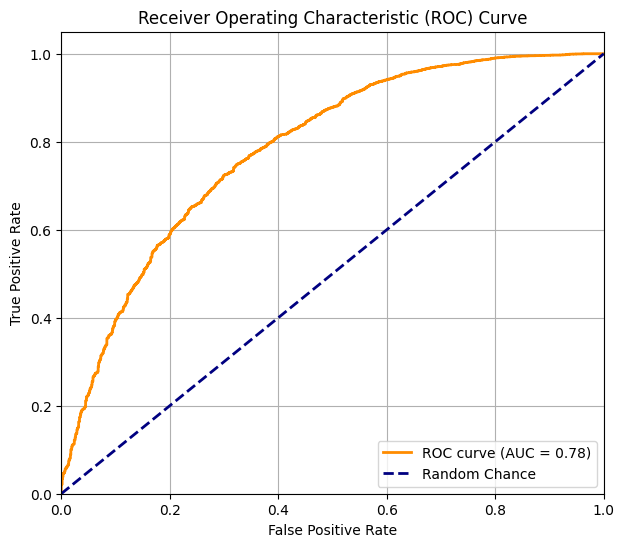

{'train_metrics': (0.7940826258024436,
  0.9534012559040156,
  0.7980126933155607,
  0.8688137996998632,
  0.8735801403116829),
 'test_metrics': (0.7570180547466512,
  0.9270951993490643,
  0.7766871165644171,
  0.8452522255192878,
  0.7833485480572597)}

In [59]:
evaluate_classification_model_binary(xgb2 , xtrain1 , ytrain1 , xtest1 , ytest1)

In [60]:
# saving the lr4 model 

import joblib 
joblib.dump(lr4 , "../artifacts/models/lr4_binary_classification_model.joblib")

['../artifacts/models/lr4_binary_classification_model.joblib']